2026-02-16 21:35:51.610930: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Cargando datos...
Reduciendo dataset de entrenamiento: Usando 2 de 9 motores.
Forma de X_train (reducido): (1060535, 32)
Generando ventanas (Step=10)...
Input Shape Train Final: (106045, 50, 32)
Input Shape Test Final: (372274, 50, 32)


/opt/miniconda3/envs/tesis_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 212.1754 - val_loss: 9.5019
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - loss: 40.5684 - val_loss: 1.7244
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 27s 146ms/step - loss: 30.8176 - val_loss: 1.8179
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - loss: 26.3315 - val_loss: 2.9701
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - loss: 26.4062 - val_loss: 1.9859
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 22.7428 - val_loss: 1.4103
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - loss: 22.1582 - val_loss: 1.1670
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - loss: 20.5471 - val_loss: 2.4816
Epoch 9/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - loss: 19.8891 - val_loss: 2.5568
Epoch 10/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - loss: 18.4850 - val_loss: 2.8288
Epoch 11/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - loss: 20.2505 - val_loss: 4.2046
Epoch 1

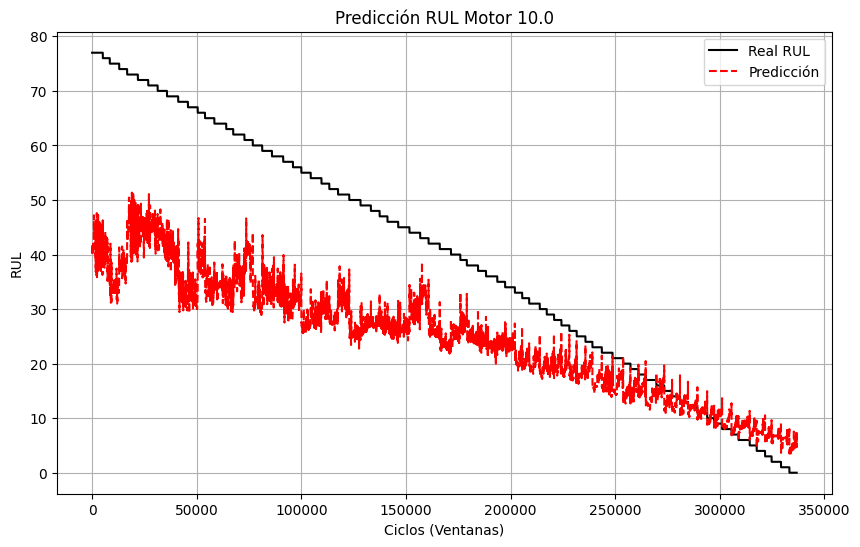

In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. CONFIGURACIÓN (MODO AHORRO DE MEMORIA)
# ==========================================
filename = 'N-CMAPSS_DS08a-009.h5' 
WINDOW_SIZE = 50   
BATCH_SIZE = 512
EPOCHS = 15

# --- PARÁMETROS DE REDUCCIÓN ---
# Usar solo el 30% de los motores disponibles para entrenar (0.1 = 10%, 1.0 = 100%)
TRAIN_RATIO = 0.3  

# Salto al crear ventanas (Downsampling). 
# 1 = toma todas las ventanas posibles (máxima memoria).
# 10 = toma 1 ventana cada 10 segundos. Reduce el tamaño del dataset en 10x.
WINDOW_STEP = 10  

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        # Development set (Train)
        W_dev = np.array(hdf.get('W_dev'))
        X_s_dev = np.array(hdf.get('X_s_dev'))
        X_v_dev = np.array(hdf.get('X_v_dev'))
        Y_dev = np.array(hdf.get('Y_dev'))
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Test set
        W_test = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test = np.array(hdf.get('Y_test'))
        A_test = np.array(hdf.get('A_test'))
        
        # Corrección de lectura de variables
        A_var = np.array(hdf.get('A_var'))
        A_var = list(np.array(A_var, dtype='U20'))
        
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print("Cargando datos...")
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W, test_Xs, test_Xv, test_Y, test_A), A_var = load_data(filename)

# ==========================================
# 2. REDUCCIÓN DE MOTORES (TRAIN)
# ==========================================
# Identificar unidades únicas en entrenamiento
train_units = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep = int(n_units_original * TRAIN_RATIO)

# Seleccionar solo las primeras N unidades
keep_units = train_units[:n_units_keep]

print(f"Reduciendo dataset de entrenamiento: Usando {n_units_keep} de {n_units_original} motores.")

# Filtrar los arrays de entrenamiento
# Buscamos los índices donde la columna unit (0) esté en nuestra lista keep_units
mask_train = np.isin(train_A[:, 0], keep_units)

train_W = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y = train_Y[mask_train]
train_A = train_A[mask_train]

# ==========================================
# 3. PREPROCESAMIENTO Y ESCALADO
# ==========================================
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train (reducido): {X_train_scaled.shape}")

# ==========================================
# 4. GENERACIÓN DE VENTANAS CON SALTO (STEP)
# ==========================================
def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows = []
    y_windows = []
    
    for unit in unique_units:
        idx = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        
        num_samples = len(unit_X)
        if num_samples < window_size:
            continue
            
        # APLICAMOS EL STEP AQUÍ PARA REDUCIR DATOS
        for i in range(0, num_samples - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            
    return np.array(X_windows), np.array(y_windows)

print(f"Generando ventanas (Step={WINDOW_STEP})...")
# Entrenamos con salto para ahorrar memoria
X_train_w, y_train_w = create_windows(X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP)

# Para test, generalmente queremos evaluar todo, pero si falla memoria, aumenta el step aquí también
X_test_w, y_test_w = create_windows(X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10) 

print(f"Input Shape Train Final: {X_train_w.shape}")
print(f"Input Shape Test Final: {X_test_w.shape}")

# ==========================================
# 5. MODELO CNN
# ==========================================
input_shape = (X_train_w.shape[1], X_train_w.shape[2])

model = models.Sequential()
model.add(layers.Conv1D(32, 3, activation='relu', input_shape=input_shape, padding='same'))
model.add(layers.Conv1D(32, 3, activation='relu', padding='same'))
model.add(layers.Conv1D(64, 3, activation='relu', padding='same'))
model.add(layers.Conv1D(64, 3, activation='relu', padding='same'))
model.add(layers.Conv1D(64, 3, activation='relu', padding='same'))
model.add(layers.Flatten())
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(1)) 

model.compile(optimizer='adam', loss='mse')

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
history = model.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 7. EVALUACIÓN
# ==========================================
print("Prediciendo...")
y_pred = model.predict(X_test_w)
rmse = np.sqrt(mean_squared_error(y_test_w, y_pred))
print(f"\nRMSE Global en Test: {rmse:.4f}")

# Visualización (Primer motor del test)
test_units = np.unique(test_A[:, 0])
target_unit = test_units[0]
idx_unit = np.where(test_A[:, 0] == target_unit)[0]

# Extraemos solo datos de ese motor para graficar limpio
unit_X_scaled = X_test_scaled[idx_unit]
unit_y_raw = test_Y[idx_unit]
# Usamos step=1 aquí para tener la gráfica bonita y suave, aunque tarde un poco más en predecir
X_unit_w, y_unit_w = create_windows(unit_X_scaled, unit_y_raw, test_A[idx_unit], WINDOW_SIZE, step=1)
y_unit_pred = model.predict(X_unit_w)

plt.figure(figsize=(10, 6))
plt.plot(y_unit_w, label='Real RUL', color='black')
plt.plot(y_unit_pred, label='Predicción', color='red', linestyle='--')
plt.title(f'Predicción RUL Motor {target_unit}')
plt.xlabel('Ciclos (Ventanas)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# Guardar el modelo en formato Keras nativo o H5
model.save('cnn_baseline_rmse_8.13.keras') 
print("¡Modelo guardado!")

¡Modelo guardado!


Total de motores en test: 6
IDs disponibles: [10. 11. 12. 13. 14. 15.]

Procesando motor 11.0...


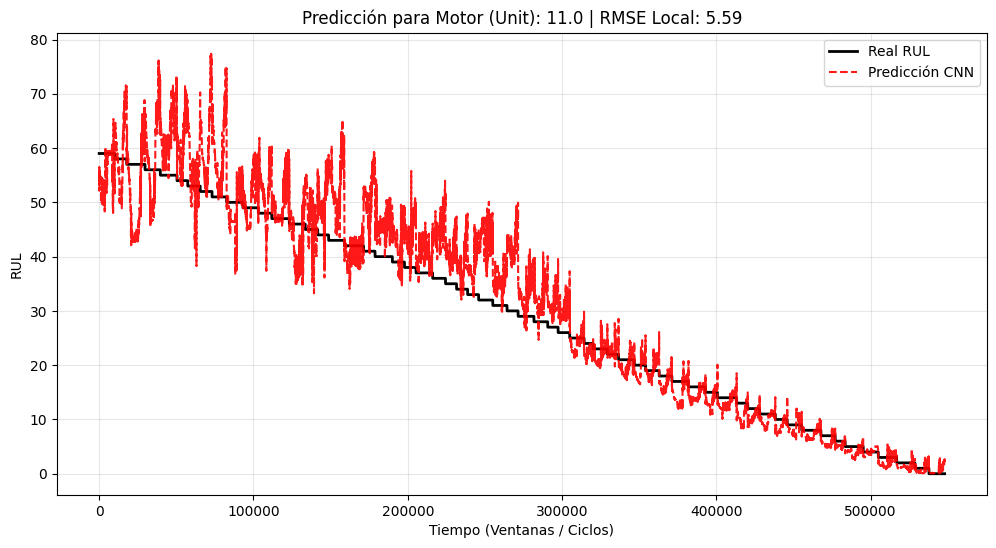

Procesando motor 10.0...


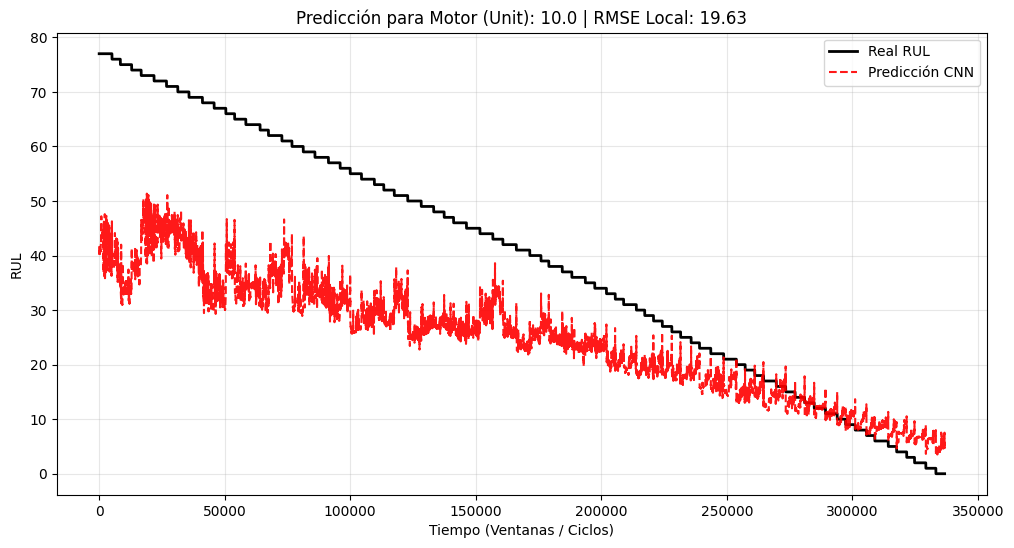

In [3]:
def visualize_test_unit(unit_id):
    """
    Visualiza la predicción de RUL para un motor específico del set de Test.
    """
    print(f"Procesando motor {unit_id}...")
    
    # 1. Encontrar índices de este motor en el test set
    idx = np.where(test_A[:, 0] == unit_id)[0]
    
    if len(idx) == 0:
        print(f"Error: La unidad {unit_id} no está en el set de Test.")
        return

    # 2. Extraer datos crudos escalados de ese motor
    unit_X = X_test_scaled[idx]
    unit_y = test_Y[idx]
    
    # 3. Crear ventanas (Step=1 para que la gráfica se vea suave y continua)
    X_w, y_w = create_windows(unit_X, unit_y, test_A[idx], WINDOW_SIZE, step=1)
    
    if len(X_w) == 0:
        print(f"Advertencia: La unidad {unit_id} tiene menos datos que el tamaño de ventana.")
        return

    # 4. Predecir
    y_pred = model.predict(X_w, verbose=0)
    
    # 5. Calcular RMSE local (solo para este motor)
    rmse_unit = np.sqrt(mean_squared_error(y_w, y_pred))
    
    # 6. Graficar
    plt.figure(figsize=(12, 6))
    plt.plot(y_w, label='Real RUL', color='black', linewidth=2)
    plt.plot(y_pred, label='Predicción CNN', color='red', linestyle='--', alpha=0.9)
    plt.title(f'Predicción para Motor (Unit): {unit_id} | RMSE Local: {rmse_unit:.2f}')
    plt.xlabel('Tiempo (Ventanas / Ciclos)')
    plt.ylabel('RUL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- ZONA DE PRUEBAS ---

# Obtener lista de todos los motores disponibles en test
all_test_units = np.unique(test_A[:, 0])
print(f"Total de motores en test: {len(all_test_units)}")
print(f"IDs disponibles: {all_test_units}\n")

# 1. Prueba con el SEGUNDO motor de la lista
visualize_test_unit(all_test_units[1])

# 2. Prueba con un motor aleatorio para ver qué pasa
import random
random_unit = random.choice(all_test_units)
visualize_test_unit(random_unit)

# 3. (Opcional) Buscar el PEOR caso para ver dónde falla
# Descomenta esto si quieres auditar a fondo:
# for unit in all_test_units[:5]: # Probar los primeros 5
#    visualize_test_unit(unit)